# Import Library

In [ ]:
!pip install roboflow

import os
import torch
import cv2
import numpy as np
import yaml
import random
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

from roboflow import Roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 40.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


# Load Dataset

In [ ]:
rf = Roboflow(api_key="DMHL8O9yQpN258YC17qG")
project = rf.workspace("nirmalas-workspace").project("awan-analisis-cuaca")
version = project.version(6)
dataset = version.download("yolov8")
dataset_path = dataset.location

print("Dataset di:", dataset_path)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Awan-analisis-cuaca-6 in yolov8:: 100%|██████████| 2357/2357 [00:00<00:00, 2540.27it/s]

Dataset di: /content/Awan-analisis-cuaca-6


In [ ]:
yaml_path = f"{dataset_path}/data.yaml"

with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml['names']
print("Class:", class_names)

Class: ['altocumulus', 'cumulonimbus', 'cumulus', 'nimbostratus']


📊 Distribusi Dataset:

altocumulus          :   364 (25.49%)
cumulonimbus         :   354 (24.79%)
cumulus              :   350 (24.51%)
nimbostratus         :   360 (25.21%)


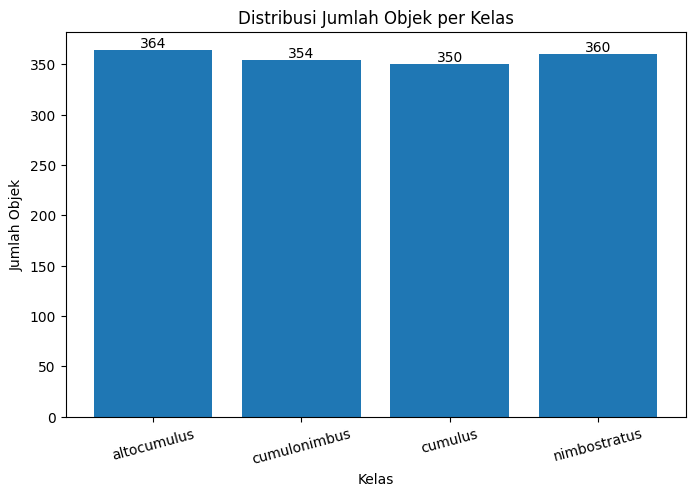

In [ ]:
import os
import glob
import yaml
import matplotlib.pyplot as plt

# Load class names
yaml_path = f"{dataset_path}/data.yaml"
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml['names']

# Hitung jumlah objek per kelas
class_counts = {name: 0 for name in class_names}

splits = ['train', 'valid', 'test']

for split in splits:
    label_files = glob.glob(f"{dataset_path}/{split}/labels/*.txt")

    for file in label_files:
        with open(file, 'r') as f:
            for line in f.readlines():
                data = list(map(float, line.strip().split()))
                if len(data) == 0:
                    continue

                class_id = int(data[0])
                class_counts[class_names[class_id]] += 1

# ========================
# TAMPILKAN HASIL
# ========================
print("📊 Distribusi Dataset:\n")

total = sum(class_counts.values())
for k, v in class_counts.items():
    persen = (v / total) * 100 if total > 0 else 0
    print(f"{k:20} : {v:5d} ({persen:.2f}%)")

# ========================
# VISUALISASI BAR CHART
# ========================
plt.figure(figsize=(8,5))
bars = plt.bar(class_counts.keys(), class_counts.values())

plt.title("Distribusi Jumlah Objek per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Objek")
plt.xticks(rotation=15)

# angka di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom')

plt.show()

In [ ]:
IMG_SIZE = 800

class CustomDataset(Dataset):
    def __init__(self, split):
        self.img_dir = f"{dataset_path}/{split}/images"
        self.label_dir = f"{dataset_path}/{split}/labels"
        self.imgs = [f for f in os.listdir(self.img_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_name = self.imgs[idx]

        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace('.jpg', '.txt'))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        img = torch.tensor(img/255.0, dtype=torch.float32).permute(2,0,1)

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = list(map(float, line.strip().split()))

                    cls = int(data[0]) + 1  # background = 0
                    coords = data[1:]

                    if len(coords) == 4:
                        cx, cy, w, h = coords

                        xmin = (cx - w/2) * IMG_SIZE
                        ymin = (cy - h/2) * IMG_SIZE
                        xmax = (cx + w/2) * IMG_SIZE
                        ymax = (cy + h/2) * IMG_SIZE

                    else:
                        xs = coords[0::2]
                        ys = coords[1::2]

                        xmin = min(xs) * IMG_SIZE
                        ymin = min(ys) * IMG_SIZE
                        xmax = max(xs) * IMG_SIZE
                        ymax = max(ys) * IMG_SIZE

                    # Clamp biar aman
                    xmin = max(0, xmin)
                    ymin = max(0, ymin)
                    xmax = min(IMG_SIZE, xmax)
                    ymax = min(IMG_SIZE, ymax)

                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(cls)

        # Kalau tidak ada objek
        if len(boxes) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels}

        return img, target

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = CustomDataset('train')
val_dataset = CustomDataset('valid')
test_dataset = CustomDataset('test')

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

print("Total train:", len(train_dataset))

Total train: 1086


In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_classes = len(class_names) + 1  # + background

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 136MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

EPOCHS = 20

print("🚀 Training dimulai...\n")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

🚀 Training dimulai...

Epoch 1 Loss: 0.2121
Epoch 2 Loss: 0.1427
Epoch 3 Loss: 0.1232
Epoch 4 Loss: 0.1023
Epoch 5 Loss: 0.0897
Epoch 6 Loss: 0.0772
Epoch 7 Loss: 0.0690
Epoch 8 Loss: 0.0631
Epoch 9 Loss: 0.0555
Epoch 10 Loss: 0.0515
Epoch 11 Loss: 0.0471
Epoch 12 Loss: 0.0434
Epoch 13 Loss: 0.0410
Epoch 14 Loss: 0.0384
Epoch 15 Loss: 0.0365
Epoch 16 Loss: 0.0337
Epoch 17 Loss: 0.0343
Epoch 18 Loss: 0.0326
Epoch 19 Loss: 0.0299
Epoch 20 Loss: 0.0280


In [ ]:
!pip install torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import time

model.eval()

metric = MeanAveragePrecision(iou_type="bbox")

start = time.time()

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        preds = model(images)

        preds_cpu = []
        targets_cpu = []

        for p, t in zip(preds, targets):
            preds_cpu.append({
                "boxes": p["boxes"].cpu(),
                "scores": p["scores"].cpu(),
                "labels": p["labels"].cpu()
            })

            targets_cpu.append({
                "boxes": t["boxes"].cpu(),
                "labels": t["labels"].cpu()
            })

        metric.update(preds_cpu, targets_cpu)

end = time.time()

result = metric.compute()

print("\n🎯 HASIL EVALUASI:")
print(f"mAP@50-95 : {result['map']:.4f}")
print(f"mAP@50    : {result['map_50']:.4f}")
print(f"Recall    : {result['mar_100']:.4f}")

print(f"\n⏱ Speed: {(end-start)/len(test_dataset)*1000:.2f} ms/image")


🎯 HASIL EVALUASI:
mAP@50-95 : 0.4618
mAP@50    : 0.6904
Recall    : 0.5674

⏱ Speed: 111.57 ms/image


In [ ]:
from torchvision.ops import box_iou
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_targets = []

IOU_THRESH = 0.5
CONF_THRESH = 0.5

model.eval()

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        preds = model(images)

        for pred, target in zip(preds, targets):

            pred_boxes = pred["boxes"].cpu()
            pred_labels = pred["labels"].cpu()
            pred_scores = pred["scores"].cpu()

            gt_boxes = target["boxes"].cpu()
            gt_labels = target["labels"].cpu()

            # filter confidence
            keep = pred_scores >= CONF_THRESH
            pred_boxes = pred_boxes[keep]
            pred_labels = pred_labels[keep]

            if len(pred_boxes) == 0 or len(gt_boxes) == 0:
                continue

            # hitung IoU
            ious = box_iou(pred_boxes, gt_boxes)

            for i in range(len(pred_boxes)):
                max_iou, idx = torch.max(ious[i], dim=0)

                if max_iou >= IOU_THRESH:
                    all_preds.append(int(pred_labels[i]) - 1)
                    all_targets.append(int(gt_labels[idx]) - 1)

In [ ]:
import torch

torch.save(model.state_dict(), "Model_FasterRCNN_AWAN_best.pth")
print("✅ Model disimpan di local runtime!")

✅ Model disimpan di local runtime!


In [ ]:
from google.colab import files
import os

filename = "Model_FasterRCNN_AWAN_best.pth"

if os.path.exists(filename):
    files.download(filename)
else:
    print(f"Error: File '{filename}' not found. Please ensure the model was saved correctly in the current runtime.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

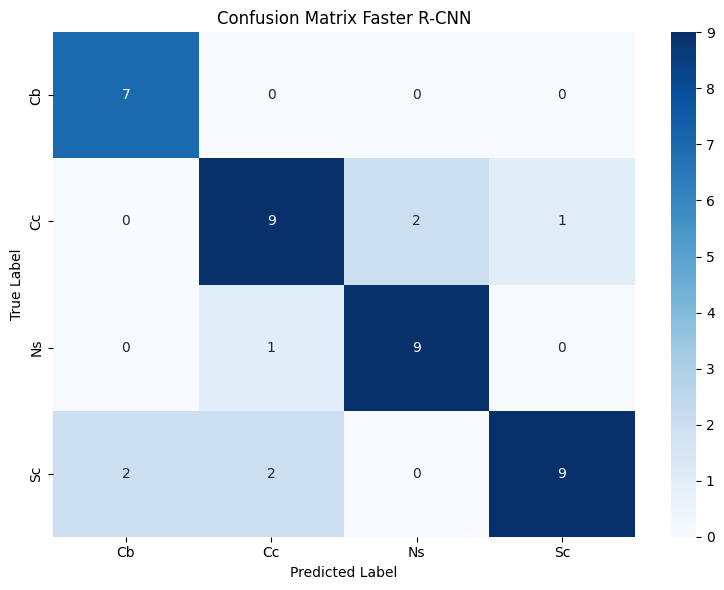

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Use the class_names loaded from data.yaml
# (Assuming class_names from data.yaml is available in the global scope)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Faster R-CNN")

plt.tight_layout()

# simpan
plt.savefig("confusion_matrix_fasterrcnn.png", dpi=300)

plt.show()